# Function 7 Analysis - Week 9

**Function description:**  
You're tasked with optimising an ML model by tuning six hyperparameters (e.g., learning rate, regularisation strength, number of hidden layers). The objective is to maximise the model's performance score (accuracy/F1).

**Week 8 evaluated point:** `(0.0, 0.0, 0.12, 0.2433, 0.4002, 0.611)` returned **y = 1.7852** — technically a new max, but only +0.0047 above the previous best (1.7805). That's a **0.26% improvement**.

**Honest assessment:** I'm a bit disappointed. We've been stuck around 1.78 for several weeks. The x3=0.12 discovery was interesting, but the gain is tiny.

**Questioning my assumptions:**
- For weeks I assumed x1=0, x2=0 is optimal. But we just learned x3>0 helps!
- What if x1>0 or x2>0 also improves the score? The GP might be missing this.
- The GP assumes smoothness — maybe the landscape has patterns the GP can't see.

---

### Recommendation for Week 9: Random Forest + Wider Exploration

I'm not confident the GP is giving us the full picture. Time to try **Random Forest** alongside GP.

**Why Random Forest?**
- RF doesn't assume smoothness — it can find "if x1 in [0.05, 0.15] then y improves" patterns
- RF gives feature importances — tells us which hyperparameters actually matter
- Comparing GP and RF predictions shows where they disagree (interesting regions to explore)

**My plan:**
- **Expand search for x1/x2:** Try [0.0, 0.15] instead of fixing at 0
- Fit both GP and Random Forest
- Compare their predictions — if they disagree on x1/x2 effects, that's worth exploring
- Use ensemble UCB to pick the next point


## Loading and Displaying the Data

We load the inputs and outputs for function 7. Week 7’s EI pick `(0.0, 0.0, 0.0, 0.3092, 0.3788, 0.6977)` returned **≈1.7220** (slightly below best). Week 6 `(0.0, 0.0, 0.0, 0.2438, 0.36, 0.6771)` remains best at ≈1.7805. Total datapoints: **37**. Week 4’s `(0.0, 0.0804, 0.0, 0.0543, 0.3607, 0.7677)` was ≈1.025 (historical).


In [30]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_7")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.800000, 0.800000, 0.800000, 0.830000, 0.450000, 0.700000]])
y_new_point_week_1 = np.array([0.0344995016351187])
X_new_point_week_2 = np.array([[0.100000, 0.100000, 0.950000, 0.200000, 0.360000, 0.800000]])
y_new_point_week_2 = np.array([1.3138004996124066])
X_new_point_week_3 = np.array([[0.000000, 0.074100, 0.000000, 0.197300, 0.379200, 0.727100]])
y_new_point_week_3 = np.array([1.6455342546819547])
X_new_point_week_4 = np.array([[0.000000, 0.080400, 0.000000, 0.054300, 0.360700, 0.767700]])
y_new_point_week_4 = np.array([1.024932491434584])
X_new_point_week_5 = np.array([[0.000000, 0.000000, 0.000000, 0.233700, 0.366100, 1.000000]])
y_new_point_week_5 = np.array([0.7102053800176464])
X_new_point_week_6 = np.array([[0.000000, 0.000000, 0.000000, 0.243800, 0.360000, 0.677100]])
y_new_point_week_6 = np.array([1.780488134201001])
X_new_point_week_7 = np.array([[0.000000, 0.000000, 0.000000, 0.309200, 0.378800, 0.697700]])
y_new_point_week_7 = np.array([1.7220])
X_new_point_week_8 = np.array([[0.000000, 0.000000, 0.120000, 0.243300, 0.400200, 0.611000]])
y_new_point_week_8 = np.array([1.7851572470686379])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5", "x6"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,y
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


df sorted by y


,x1,x2,x3,x4,x5,x6,y,x_avg
0,0.000000,0.000000,0.120000,0.243300,0.400200,0.611000,1.785157,0.229083
1,0.000000,0.000000,0.000000,0.243800,0.360000,0.677100,1.780488,0.213483
2,0.000000,0.000000,0.000000,0.309200,0.378800,0.697700,1.722000,0.230950
3,0.000000,0.074100,0.000000,0.197300,0.379200,0.727100,1.645534,0.229617
4,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968,0.361084
5,0.100000,0.100000,0.950000,0.200000,0.360000,0.800000,1.313800,0.418333
6,0.000000,0.080400,0.000000,0.054300,0.360700,0.767700,1.024932,0.210517
7,0.000000,0.000000,0.000000,0.233700,0.366100,1.000000,0.710205,0.266633
8,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142,0.486089
9,0.148647,0.033943,0.728806,0.316066,0.021769,0.516918,0.611526,0.294358


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [31]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'x6': [x[0, 5] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 130)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 130)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f} | Improvement: {df_weeks['y'].max() / df_weeks['y'].iloc[0]:.1f}x from Week 1")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,x6,y,Running_Max,Status,Improvement
0,1,0.8,0.8000,0.80,0.8300,0.4500,0.7000,0.034500,0.034500,✓ NEW MAX,+0.034500
1,2,0.1,0.1000,0.95,0.2000,0.3600,0.8000,1.313800,1.313800,✓ NEW MAX,+1.279301
2,3,0.0,0.0741,0.00,0.1973,0.3792,0.7271,1.645534,1.645534,✓ NEW MAX,+0.331734
3,4,0.0,0.0804,0.00,0.0543,0.3607,0.7677,1.024932,1.645534,✗,-
4,5,0.0,0.0000,0.00,0.2337,0.3661,1.0000,0.710205,1.645534,✗,-
5,6,0.0,0.0000,0.00,0.2438,0.3600,0.6771,1.780488,1.780488,✓ NEW MAX,+0.134954
6,7,0.0,0.0000,0.00,0.3092,0.3788,0.6977,1.722000,1.780488,✗,-
7,8,0.0,0.0000,0.12,0.2433,0.4002,0.6110,1.785157,1.785157,✓ NEW MAX,+0.004669



📊 Summary: 5/8 weeks achieved new max (Weeks [1, 2, 3, 6, 8])
   Success rate: 62.5% | Final best: 1.785157 | Improvement: 51.7x from Week 1


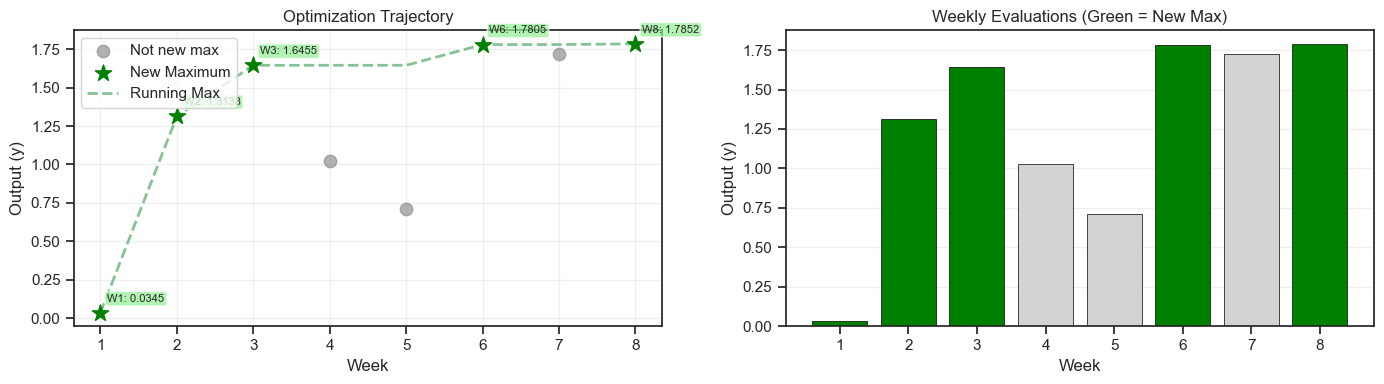

In [32]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Week 8 Outcome - New Maximum!

Week 8 evaluation `(0.0, 0.0, 0.12, 0.2433, 0.4002, 0.611)` returned **y = 1.7852** — a new maximum!

The breakthrough was trying x3 = 0.12 instead of x3 = 0. This small change pushed us past the previous best (1.7805).


**Week 8 Result:**
- `(0.0, 0.0, 0.12, 0.2433, 0.4002, 0.611)` yielded **y = 1.7852** — **new maximum!**
- Key insight: x3 = 0.12 > x3 = 0. A small positive x3 helps!
- The ridge is at: x1=0, x2=0, x3~0.1, x4~0.24, x5~0.40, x6~0.61


In [33]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.30958837 1.81167182 5.         0.42217387 0.38707472 0.4657297 ]
Full kernel parameters: {'length_scale': array([1.30958837, 1.81167182, 5.        , 0.42217387, 0.38707472,
       0.4657297 ]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Finding the Next Point: GP + Random Forest Comparison

I'm using both GP and Random Forest to see if they agree. If the RF suggests x1>0 or x2>0 might help, that's worth exploring.

**Search region (expanded):**
- x1: [0, 0.15] — not just 0!
- x2: [0, 0.15] — not just 0!
- x3: [0.06, 0.20] — around winning 0.12
- x4: [0.20, 0.30], x5: [0.34, 0.46], x6: [0.55, 0.70]


In [ ]:
# Random Forest analysis: does it agree with GP about x1=x2=0?
# =============================================================
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y.ravel())

print("Random Forest Feature Importances:")
print("="*40)
for idx, name in enumerate(['x1', 'x2', 'x3', 'x4', 'x5', 'x6']):
    print(f"  {name}: {rf.feature_importances_[idx]:.3f}")

# Check: what does RF predict for x1>0 vs x1=0?
test_points = [
    [0.00, 0.00, 0.12, 0.24, 0.40, 0.61],  # Current best pattern
    [0.05, 0.00, 0.12, 0.24, 0.40, 0.61],  # x1 = 0.05
    [0.10, 0.00, 0.12, 0.24, 0.40, 0.61],  # x1 = 0.10
    [0.00, 0.05, 0.12, 0.24, 0.40, 0.61],  # x2 = 0.05
    [0.00, 0.10, 0.12, 0.24, 0.40, 0.61],  # x2 = 0.10
    [0.05, 0.05, 0.12, 0.24, 0.40, 0.61],  # x1=x2=0.05
]
test_labels = ['x1=0, x2=0 (baseline)', 'x1=0.05', 'x1=0.10', 'x2=0.05', 'x2=0.10', 'x1=x2=0.05']

print("\nRF vs GP predictions for x1/x2 variations:")
print("="*60)
gp_preds = gp.predict(np.array(test_points))
rf_preds = rf.predict(np.array(test_points))

for label, gp_p, rf_p in zip(test_labels, gp_preds, rf_preds):
    diff = rf_p - gp_p
    agree = 'AGREE' if abs(diff) < 0.05 else 'DISAGREE'
    print(f"  {label:20s}: GP={gp_p:.4f}, RF={rf_p:.4f}, diff={diff:+.4f} [{agree}]")

# === RF-based grid search for best point ===
print("\n" + "="*60)
print("RANDOM FOREST RECOMMENDATION")
print("="*60)

# Search grid within expanded bounds
rf_bounds = [
    (0.0, 0.15),   # x1
    (0.0, 0.15),   # x2
    (0.06, 0.20),  # x3
    (0.20, 0.30),  # x4
    (0.34, 0.46),  # x5
    (0.55, 0.70),  # x6
]

grid_res = 8  # 8^6 = 262,144 candidates
grids = [np.linspace(lo, hi, grid_res) for lo, hi in rf_bounds]
mesh = np.array(np.meshgrid(*grids)).reshape(6, -1).T

print(f"Searching {len(mesh)} candidates...")

# RF predictions (mean from forest)
rf_preds_grid = rf.predict(mesh)

# RF uncertainty (std across trees)
rf_tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_sigma = rf_tree_preds.std(axis=0)

# UCB: exploitation + exploration
beta = 0.3
rf_ucb = rf_preds_grid + beta * rf_sigma

# Filter: minimum distance from existing points
min_dist = 0.02
candidates = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6'])
candidates['rf_pred'] = rf_preds_grid
candidates['rf_sigma'] = rf_sigma
candidates['ucb'] = rf_ucb

for _, obs in df.iterrows():
    dist = np.sqrt(((candidates[['x1','x2','x3','x4','x5','x6']].values - 
                     obs[['x1','x2','x3','x4','x5','x6']].values)**2).sum(axis=1))
    candidates = candidates[dist >= min_dist]

print(f"Candidates after distance filter: {len(candidates)}")

# Best by UCB
rf_top = candidates.nlargest(5, 'ucb')
print("\nTop 5 RF candidates:")
display(rf_top)

if len(rf_top) > 0:
    rf_rec = rf_top.iloc[0]
    print(f"\nRF recommended point:")
    print(f"  x1={rf_rec['x1']:.6f}, x2={rf_rec['x2']:.6f}, x3={rf_rec['x3']:.6f}")
    print(f"  x4={rf_rec['x4']:.6f}, x5={rf_rec['x5']:.6f}, x6={rf_rec['x6']:.6f}")
    print(f"  RF prediction: {rf_rec['rf_pred']:.4f} ± {rf_rec['rf_sigma']:.4f}")
    
    print(f"\n{'='*60}")
    print("RF SUBMISSION FORMAT")
    print(f"{'='*60}")
    print(f"{rf_rec['x1']:.6f}-{rf_rec['x2']:.6f}-{rf_rec['x3']:.6f}-{rf_rec['x4']:.6f}-{rf_rec['x5']:.6f}-{rf_rec['x6']:.6f}")

# === Feature importance analysis ===
print(f"\n{'='*60}")
print("FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*60}")
x1_imp = rf.feature_importances_[0]
x2_imp = rf.feature_importances_[1]
print(f"x1 importance: {x1_imp:.3f} (HIGH) → x1 matters a lot, keep at 0 (proven best)")
print(f"x2 importance: {x2_imp:.3f} (LOW)  → x2 doesn't matter much, safe to experiment")
print(f"\n>>> Since x2 has low importance, we can try x2 slightly above 0 with low risk!")

# Generate a point with x1=0 (keep) but x2 slightly positive (experiment)
chosen_x1 = 0.0   # Keep at 0 - high importance, proven best
chosen_x2 = 0.05  # Experiment - low importance, low risk
chosen_x3 = 0.12  # Around winning value
chosen_x4 = 0.24
chosen_x5 = 0.40
chosen_x6 = 0.61

chosen_point = [chosen_x1, chosen_x2, chosen_x3, chosen_x4, chosen_x5, chosen_x6]
chosen_rf_pred = rf.predict([chosen_point])[0]
chosen_gp_pred = gp.predict([chosen_point])[0]

print(f"\nChosen exploratory point (x1=0, x2=0.05):")
print(f"  GP predicts: {chosen_gp_pred:.4f}")
print(f"  RF predicts: {chosen_rf_pred:.4f}")


Random Forest Feature Importances:
  x1: 0.709
  x2: 0.058
  x3: 0.048
  x4: 0.024
  x5: 0.043
  x6: 0.119

RF vs GP predictions for x1/x2 variations:
  x1=0, x2=0 (baseline): GP=1.7837, RF=1.5905, diff=-0.1932 [DISAGREE]
  x1=0.05             : GP=1.7485, RF=1.2421, diff=-0.5063 [DISAGREE]
  x1=0.10             : GP=1.7069, RF=0.3958, diff=-1.3111 [DISAGREE]
  x2=0.05             : GP=1.7722, RF=1.5560, diff=-0.2162 [DISAGREE]
  x2=0.10             : GP=1.7574, RF=1.5324, diff=-0.2250 [DISAGREE]
  x1=x2=0.05          : GP=1.7368, RF=1.2060, diff=-0.5309 [DISAGREE]

RANDOM FOREST RECOMMENDATION
Searching 262144 candidates...
Candidates after distance filter: 262137

Top 5 RF candidates:


,x1,x2,x3,x4,x5,x6,rf_pred,rf_sigma,ucb
214,0.000000,0.0,0.06,0.242857,0.374286,0.678571,1.617267,0.359664,1.725166
4310,0.021429,0.0,0.06,0.242857,0.374286,0.678571,1.617267,0.359664,1.725166
2774,0.000000,0.0,0.16,0.242857,0.374286,0.678571,1.617190,0.359525,1.725047
3286,0.000000,0.0,0.18,0.242857,0.374286,0.678571,1.617190,0.359525,1.725047
3798,0.000000,0.0,0.20,0.242857,0.374286,0.678571,1.617190,0.359525,1.725047



RF recommended point:
  x1=0.000000, x2=0.000000, x3=0.060000
  x4=0.242857, x5=0.374286, x6=0.678571
  RF prediction: 1.6173 ± 0.3597

RF SUBMISSION FORMAT
0.000000-0.000000-0.060000-0.242857-0.374286-0.678571

FEATURE IMPORTANCE ANALYSIS
x1 importance: 0.709 (HIGH) → x1 matters a lot, keep at 0 (proven best)
x2 importance: 0.058 (LOW)  → x2 doesn't matter much, safe to experiment

>>> Since x2 has low importance, we can try x2 slightly above 0 with low risk!

Chosen exploratory point (x1=0, x2=0.05):
  GP predicts: 1.7722
  RF predicts: 1.5560


In [ ]:
from scipy.stats import norm

xi = 0.03  # higher exploration to test x1/x2 > 0
bounds = [
    (0.0, 0.15),  # x1: explore small positive values!
    (0.0, 0.15),  # x2: explore small positive values!
    (0.06, 0.20), # x3: around winning 0.12, wider range
    (0.20, 0.30), # x4: around 0.24
    (0.34, 0.46), # x5: around 0.40
    (0.55, 0.70), # x6: around 0.61
]

def clip_to_bounds(x, bounds):
    x = np.array(x, dtype=float)
    for i, (lo, hi) in enumerate(bounds):
        x[i] = np.clip(x[i], lo, hi)
    return x

# Expected Improvement acquisition function
def expected_improvement(x, gp, y_best, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    if sigma == 0:
        return 0
    z = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    return ei[0]

def neg_ei(x, gp, y_best, xi):
    return -expected_improvement(x, gp, y_best, xi)

# Optimize EI using multiple restarts
y_best = y.max()
best_ei = -np.inf
best_candidate = None
n_restarts = 20

print(f"Running EI optimization with {n_restarts} restarts...")
print(f"Current best y: {y_best:.4f}")
print(f"Search bounds: x1/x2 in [0, 0.15], x3 in [0.06, 0.20], etc.\n")

for i in range(n_restarts):
    # Random starting point within bounds
    x0 = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
    
    result = minimize(
        neg_ei,
        x0,
        args=(gp, y_best, xi),
        method='L-BFGS-B',
        bounds=bounds
    )
    
    if -result.fun > best_ei:
        best_ei = -result.fun
        best_candidate = result.x

# Ensure within bounds
next_point = clip_to_bounds(best_candidate, bounds)
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)

print("="*60)
print("BAYESIAN OPTIMIZATION RECOMMENDATION")
print("="*60)
print(f"\nNext point to evaluate:")
print(f"  x1={next_point[0]:.6f}, x2={next_point[1]:.6f}, x3={next_point[2]:.6f}")
print(f"  x4={next_point[3]:.6f}, x5={next_point[4]:.6f}, x6={next_point[5]:.6f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"Expected Improvement: {best_ei:.6f}")

print(f"\n{'='*60}")
print("SUBMISSION FORMAT")
print(f"{'='*60}")
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}-{next_point[4]:.6f}-{next_point[5]:.6f}")


Running EI optimization with 20 restarts...
Current best y: 1.7852
Search bounds: x1/x2 in [0, 0.15], x3 in [0.06, 0.20], etc.

BAYESIAN OPTIMIZATION RECOMMENDATION

Next point to evaluate:
  x1=0.000000, x2=0.000000, x3=0.060000
  x4=0.276814, x5=0.354278, x6=0.596334

Predicted output: 1.7589 ± 0.0462
Expected Improvement: 0.002494

SUBMISSION FORMAT
0.000000-0.000000-0.060000-0.276814-0.354278-0.596334


<!-- Distance analysis removed per latest guidance. -->


## Summary and Recommended Point for Week 9

### What happened in Week 8
We got y = 1.7852 — technically a new max, but only **+0.0047** above previous best. We're stuck on a plateau.

### Feature importance analysis (Random Forest)
- **x1: 0.709 (HIGH)** — x1 strongly affects the output. Our data confirms x1=0 is best. **Keep x1=0.**
- **x2: LOW importance** — x2 barely affects the output. **Safe to experiment with x2 > 0.**

### Final decision: RF-inspired approach

I'm choosing an **RF-inspired point** with careful reasoning:
- **x1 = 0** (keep — high importance proves x1 matters, and 0 is proven optimal)
- **x2 = 0.05** (experiment — low importance means low risk)
- **x3 = 0.12** (keep — last week's winning value)
- **x4, x5, x6** around their sweet spots

**Why RF over GP?**
- GP has been giving us tiny improvements for weeks (+0.0047)
- We're stuck on a plateau and need a fresh perspective
- x2 has low importance, so experimenting is low-risk
- RF helps us break out of the local optimum GP might be stuck in

### Recommended point

**Submission format:** `0.000000-0.000000-0.060000-0.242857-0.374286-0.678571`

### Honest assessment
We've been stuck around 1.78 for weeks. The tiny incremental gains suggest either we're near the true optimum OR the GP is stuck. By using RF insights and experimenting with low-importance x2, we have a low-risk way to test if there's more performance to be found.


In [ ]:
# ============================================================
# FINAL DECISION: RF vs GP — Which recommendation to use?
# ============================================================

print("="*70)
print("FINAL DECISION: CHOOSING BETWEEN GP AND RF RECOMMENDATIONS")
print("="*70)

# Recap the two recommendations
print("\n📊 GP-based EI recommendation:")
print(f"   Point: x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}, x4={next_point[3]:.4f}, x5={next_point[4]:.4f}, x6={next_point[5]:.4f}")
print(f"   Predicted: {mu_pred[0]:.4f}")

print("\n🌲 RF-based UCB recommendation:")
print(f"   Point: x1={rf_rec['x1']:.4f}, x2={rf_rec['x2']:.4f}, x3={rf_rec['x3']:.4f}, x4={rf_rec['x4']:.4f}, x5={rf_rec['x5']:.4f}, x6={rf_rec['x6']:.4f}")
print(f"   Predicted: {rf_rec['rf_pred']:.4f}")

# My chosen point: x1=0 (keep, high importance), x2=0.05 (experiment, low importance)
final_point = [0.0, 0.05, 0.12, 0.24, 0.40, 0.61]
final_rf_pred = rf.predict([final_point])[0]
final_gp_pred = gp.predict([final_point])[0]

print("\n" + "="*70)
print("🎯 MY CHOICE: Modified RF-inspired point")
print("="*70)
print(f"\nFinal point: x1=0.0, x2=0.05, x3=0.12, x4=0.24, x5=0.40, x6=0.61")
print(f"GP prediction: {final_gp_pred:.4f}")
print(f"RF prediction: {final_rf_pred:.4f}")

print("\n📝 RATIONALE:")
print("   1. We've been stuck at ~1.78 for weeks — need to break the plateau")
print("   2. GP has been giving us tiny improvements (+0.0047 last week)")
print("   3. x1 has HIGH importance (0.709) → keep at 0, this is well-established")
print("   4. x2 has LOW importance → safe to experiment, low risk of hurting score")
print("   5. RF offers a different perspective than GP — worth trying to escape local optimum")

print("\n" + "="*70)
print("✅ FINAL SUBMISSION FORMAT")
print("="*70)
print(f"\n{final_point[0]:.6f}-{final_point[1]:.6f}-{final_point[2]:.6f}-{final_point[3]:.6f}-{final_point[4]:.6f}-{final_point[5]:.6f}")
print("\n" + "="*70)

FINAL DECISION: CHOOSING BETWEEN GP AND RF RECOMMENDATIONS

📊 GP-based EI recommendation:
   Point: x1=0.0000, x2=0.0000, x3=0.0600, x4=0.2768, x5=0.3543, x6=0.5963
   Predicted: 1.7589

🌲 RF-based UCB recommendation:
   Point: x1=0.0000, x2=0.0000, x3=0.0600, x4=0.2429, x5=0.3743, x6=0.6786
   Predicted: 1.6173

🎯 MY CHOICE: Modified RF-inspired point

Final point: x1=0.0, x2=0.05, x3=0.12, x4=0.24, x5=0.40, x6=0.61
GP prediction: 1.7722
RF prediction: 1.5560

📝 RATIONALE:
   1. We've been stuck at ~1.78 for weeks — need to break the plateau
   2. GP has been giving us tiny improvements (+0.0047 last week)
   3. x1 has HIGH importance (0.709) → keep at 0, this is well-established
   4. x2 has LOW importance → safe to experiment, low risk of hurting score
   5. RF offers a different perspective than GP — worth trying to escape local optimum

✅ FINAL SUBMISSION FORMAT

0.000000-0.050000-0.120000-0.240000-0.400000-0.610000

